# Exercise E2

## Part 1 - Flat Data and Headers

In [10]:
import pandas as pd

# Define column headers
columns = ["Date", "Time", "Depth(m)", "Temperature(°C)", "Salinity(psu)"]   

# Read the .dat file
df = pd.read_csv(
    "for_nitpicker.dat",
    sep="\t",
    header=None,
    names=columns
)

# Save as CSV
df.to_csv("11_29_2008_CTD.csv", index=False)

In [11]:
print(df)

           Date   Time  Depth(m)  Temperature(°C)  Salinity(psu)
0    11/29/2008  06:52         5            28.97          35.21
1    11/29/2008  06:52         6            28.98          35.21
2    11/29/2008  06:52         7            28.99          35.21
3    11/29/2008  06:52         8            28.96          35.21
4    11/29/2008  06:52         9            28.99          35.21
..          ...    ...       ...              ...            ...
991  11/29/2008  06:52       996             6.13          34.85
992  11/29/2008  06:52       997             6.13          34.85
993  11/29/2008  06:52       998             6.12          34.85
994  11/29/2008  06:52       999             6.12          34.85
995  11/29/2008  06:52      1000             6.11          34.85

[996 rows x 5 columns]


## Part 2 - Profiles

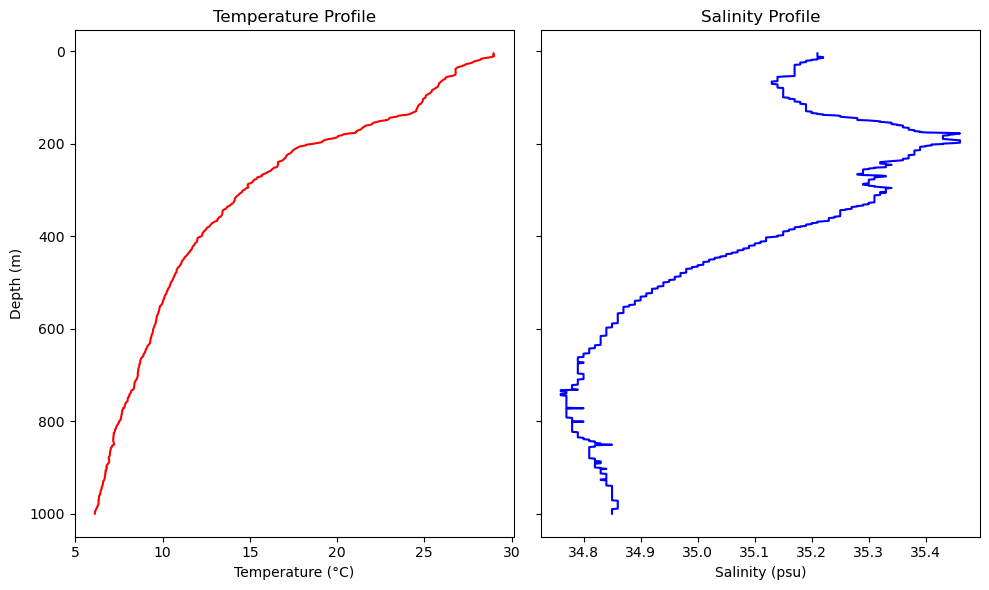

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Function to convert degrees/minutes to decimal degrees
def ddmm2dd(ddmm):
    """
    Converts a position input from degrees and minutes to degrees and decimals
    Input is ddmm.cccc and output is dd.cccc
    """
    thedeg = np.floor(ddmm / 100.)
    themin = (ddmm - thedeg * 100.) / 60.
    return thedeg + themin

# Read the prepared CSV file
df = pd.read_csv("11_29_2008_CTD.csv")

# OPTIONAL: convert latitude/longitude columns if needed
# df["Latitude"] = ddmm2dd(df["Latitude"])
# df["Longitude"] = ddmm2dd(df["Longitude"])

# Create two side-by-side panels sharing the y-axis
fig, ax = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10, 6))

# Temperature profile
ax[0].plot(df["Temperature(°C)"], df["Depth(m)"], color="red")
ax[0].set_xlabel("Temperature (°C)")
ax[0].set_ylabel("Depth (m)")
ax[0].set_title("Temperature Profile")

# Salinity profile
ax[1].plot(df["Salinity(psu)"], df["Depth(m)"], color="blue")
ax[1].set_xlabel("Salinity (psu)")
ax[1].set_title("Salinity Profile")

# Invert y-axis so depth increases downward
ax[0].invert_yaxis()

# Improve spacing
plt.tight_layout()

# Show the plot
plt.show()

## Part 3 - Time Series

Missing values per column:
id                   0
TIME_GPS           225
LATITUDE           225
N_S                225
LONGITUDE          225
E_W                225
HUMIDITY           225
BAROMETER          225
AIR_TEMPERATURE    225
WIND_SPEED_REL     225
WIND_SPEED_TRUE    228
WIND_DIR_REL       225
WIND_DIR_TRUE      228
PAR                226
TSG_SALINITY       339
TSG_TEMP           339
dtype: int64
                       id  TIME_GPS  LATITUDE N_S  LONGITUDE E_W  HUMIDITY  \
TIME_SERVER                                                                  
2017-06-28 17:10:00  1256  17:09:58  3428.595   S   1819.447   E      73.2   
2017-06-28 17:20:00  1257  17:19:58  3430.443   S   1820.241   E      65.2   
2017-06-28 17:30:00  1258  17:29:59  3432.261   S   1821.118   E      68.0   
2017-06-28 17:40:00  1259  17:40:02  3434.121   S   1821.882   E      68.0   
2017-06-28 17:50:00  1260  17:49:58  3435.981   S   1822.673   E      65.4   

                     BAROMETER  AIR_TEMPERATU

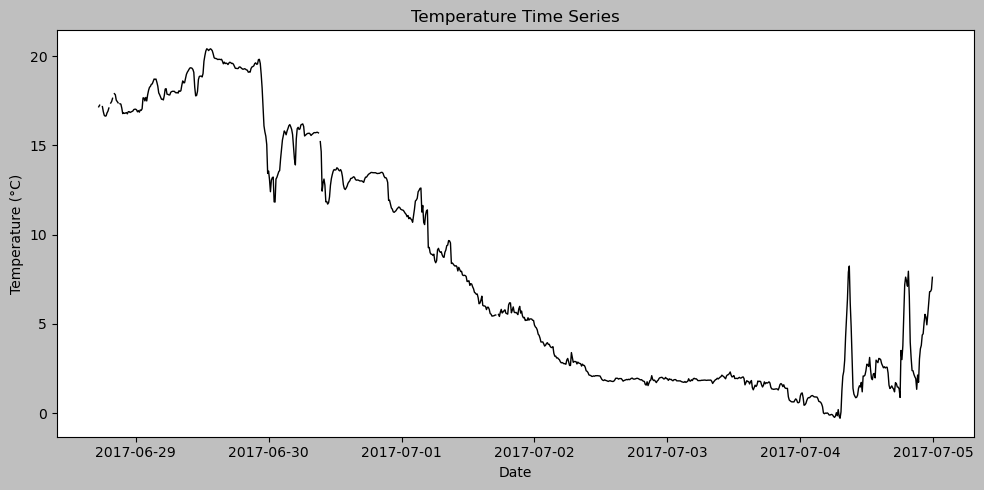

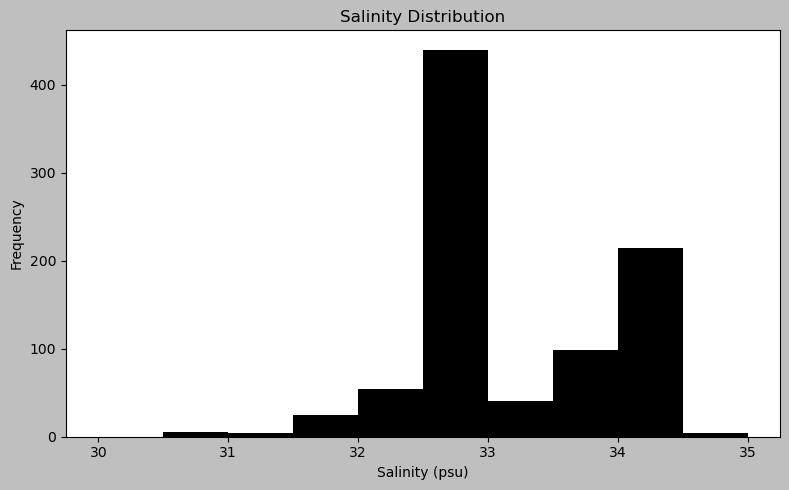


Summary Statistics:
                   Mean  Standard Deviation  Interquartile Range
TSG_TEMP       8.146541            6.747988            11.768850
TSG_SALINITY  33.110553            1.140150             1.272575


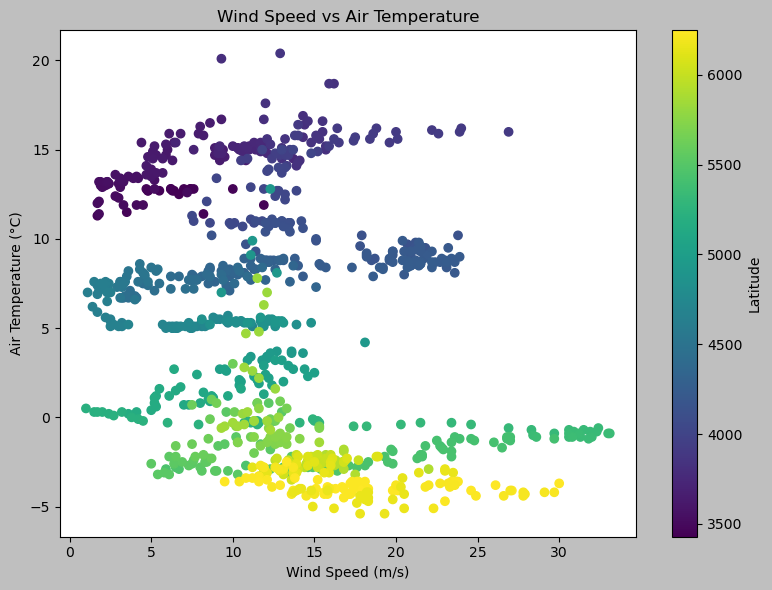

In [16]:
# --------------------------------------------------
# 1. LOAD THE CSV FILE
# --------------------------------------------------

# Load the dataset
# Replace "DateTime" with the actual time column name if different
df = pd.read_csv(
    "SAA2_WC_2017_metocean_10min_avg.csv",
    parse_dates=["TIME_SERVER"],
    index_col="TIME_SERVER",
    na_values=["NaN", "nan", "9999", "-9999", ""]
)

# Check missing values
print("Missing values per column:")
print(df.isna().sum())

# --------------------------------------------------
# SELECT DATA FROM DEPARTURE TO JULY 4TH INCLUDED
# --------------------------------------------------

selected = df.loc[:'2017-07-04']

print(selected.head())

# --------------------------------------------------
# 2. TEMPERATURE TIME SERIES
# --------------------------------------------------

# Use grayscale style
plt.style.use('grayscale')

fig, ax = plt.subplots(figsize=(10, 5))

# Replace "Temperature" with your actual column name
ax.plot(selected.index,
        selected["TSG_TEMP"],
        linewidth=1)

ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Temperature Time Series")

plt.tight_layout()

# Save figure
plt.savefig("temperature_timeseries.png")

plt.show()

# --------------------------------------------------
# 3. HISTOGRAM OF SALINITY
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

# Define bins from 30 to 35 every 0.5 psu
bins = np.arange(30, 35.5, 0.5)

# Replace "Salinity" with your actual column name
ax.hist(selected["TSG_SALINITY"].dropna(),
        bins=bins)

ax.set_xlabel("Salinity (psu)")
ax.set_ylabel("Frequency")
ax.set_title("Salinity Distribution")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 4. SUMMARY STATISTICS TABLE
# --------------------------------------------------

# Replace column names if necessary
variables = ["TSG_TEMP", "TSG_SALINITY"]

summary_table = pd.DataFrame({
    "Mean": selected[variables].mean(),
    "Standard Deviation": selected[variables].std(),
    "Interquartile Range": (
        selected[variables].quantile(0.75) -
        selected[variables].quantile(0.25)
    )
})

print("\nSummary Statistics:")
print(summary_table)

# --------------------------------------------------
# 5. SCATTER PLOT:
# WIND SPEED vs AIR TEMPERATURE
# LATITUDE ENCODED BY COLOUR
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

# Replace column names if necessary
scatter = ax.scatter(
    selected["WIND_SPEED_REL"],
    selected["AIR_TEMPERATURE"],
    c=selected["LATITUDE"],
    cmap="viridis"
)

ax.set_xlabel("Wind Speed (m/s)")
ax.set_ylabel("Air Temperature (°C)")
ax.set_title("Wind Speed vs Air Temperature")

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label("Latitude")

plt.tight_layout()

# Save as high-resolution PNG
plt.savefig("wind_airtemp_scatter.png", dpi=300)

plt.show()